In [2]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider
import datlib
from scipy.optimize import curve_fit

In [62]:
#Selección de datos
ver = ''  #Utilizado como prefijo en los archivos para no sobreescribir existentes

#Parametros de la ruta
muestra = '3'
opt = 'simultaneas'
tipo = 'dextrosa'
medicion = 'luminiscencia'

In [63]:
titulo = {
    '1':'2 horas',
    '2':'4 horas',
    '3':'8 horas',
    '4':'16 horas',
    '5':'24 horas',
    '6':'48 horas',
}
num = ord(muestra)-48
nomenclatura = []
if opt == 'normales':
    base_save = 'lorentz/normales/'+tipo+'/120/m'
    base = 'muestras/' + tipo + '/120/Muestra' + muestra + '/'
    temp = '120'
    option = medicion
else:
    base_save = 'lorentz/simultaneas/'+tipo+'/m'
    base = 'muestras/' + tipo + '/simultaneas/med' + muestra + '/'
   
    temp = '200'

    if medicion == 'luminiscencia':
        option = 'med'
    else:
        option = 'lum'
    
ruta_open = base
ruta_save = base_save + muestra + '/'

print(ruta_open)

muestras/dextrosa/simultaneas/med3/


In [64]:
datos = datlib.comparison(ruta_open, option, )

Definición de parámetros iniciales y límites para el ajuste

In [17]:
bounds_inf = [
    -0.5,          # y0
    10.,  83.,  183.,        # w > 0
    0.,  89.,  250.,        # A > 0
    475.,510.,550.       # x0 mínimos
]

bounds_sup = [
    -0.45,           # y0
    12.,87.,187.,      # w máximos
    2.,95.,260.,  # A
    485.,520.,570.       # x0 máximos
]

p0 = np.array([-0.47, 11.0,85.0,185.0,1.4,91.0,253.0,481.0,515.0,554.0])
p02 = np.array([0.0, 20.,20., 100.,100., 500.,520.])

In [24]:
bounds_inf = [
    -1.0,          # y0
    1.,  1.,  1.,        # w > 0
    0.,  0.,  0.,        # A > 0
    460.,470.,510.       # x0 mínimos
]

bounds_sup = [
    1.0,           # y0
    60.,100.,100.,      # w máximos
    10.,100.,100.,  # A
    480.,510.,540.       # x0 máximos
]

bounds_inf2 = [
    -1.0,          # y0
    1.,  1.,        # w > 0
    0.,  0.,        # A > 0
    470.,510.       # x0 mínimos
]

bounds_sup2 = [
    1.0,           # y0
    100.,100.,      # w máximos
    100.,100.,  # A
    510.,540.       # x0 máximos
]
p0 = np.array([-0.34826999999999997,45.64767,49.05249,74.92107,5.0,34.12075,49.9684,460.0588,500.0,530.0])
p02 = np.array([-0.34826999999999997,45.64767,49.05249,5.0,34.12075,500.0,530.0])

In [65]:
bounds_inf = [-1.3482699999999999,1.0,1.0,1.0,0.0,0.0,0.0,481.0588,504.61706000000004,528.50106]
bounds_sup = [0.65173,145.64767,149.05249,174.92107,146.87971,134.12075,149.9684,521.0588,544.61706,568.50106]
p0 = np.array([-0.34826999999999997,45.64767,49.05249,74.92107,46.87971,34.12075,49.9684,501.0588,524.61706,548.50106])

bounds_inf2 = [-1.3482699999999999,1.0,1.0,0.0,0.0,504.61706000000004,528.50106]
bounds_sup2 = [0.65173,149.05249,174.92107,134.12075,149.9684,544.61706,568.50106]
p02 = np.array([-0.34826999999999997,49.05249,74.92107,34.12075,49.9684,524.61706,548.50106])

In [99]:
bounds_inf = [
    -10.0,          # y0
    1.,  70.,  1.,        # w > 0
    0.,  0.,  10.,        # A > 0
    455.,500.,500.       # x0 mínimos
]

bounds_sup = [
    1.0,           # y0
    60.,1000.,1000.,      # w máximos
    10.,100.,1000.,  # A
    480.,520.,585.       # x0 máximos
]
bounds_inf2 = [
    -1.0,          # y0
     1.,  1.,        # w > 0
      0.,  0.,        # A > 0
    470.,510.       # x0 mínimos
]

bounds_sup2 = [
    1.0,           # y0
   1000.,1000.,      # w máximos
    100.,1000.,  # A
    550.,580.       # x0 máximos
]

#p0 = np.array([-5.34826999999999997,25.64767,100.05249,74.92107,5.0,4.12075,100.9684,460.0588,500.61706,508.50106])
p0 = np.array([-0.24, 17.0,80.0,141.0,2.5,93.0,140.0,478.0,515.0,560.0])

In [312]:
bounds_inf = [-2.8315457218568154,1.0,0.0,559.9999999999922]
bounds_sup = [-0.8315457218568154,278.52824088169524,530.9976665104384,599.9999999999922]
p0 = np.array([-1.8315457218568154,178.52824088169524,430.99766651043836,579.9999999999922])

In [66]:
wavelength = datos.wavelength
fibra1 = np.copy(datos.datos[0])
factor_recon = datos.espectro[0,:]
fibra2 = np.copy(np.array(datos.datos[1]))
bajar = True        #True si se requiere quitar offset a los datos para que el mínimo sea 0
recon = True        #Opción para mediciones comparativas
for i in range(datos.n):
    if recon:
        fibra2[i] *=factor_recon
    maxi = max(fibra2[i])
    fibra2[i] = fibra2[i]/maxi
    maxi = max(fibra1[i])
    fibra1[i] = fibra1[i]/maxi
    if bajar:
        fibra1[i] = fibra1[i] - min(fibra1[i])
        fibra2[i] = fibra2[i] - min(fibra2[i])
cut_array = True    #Si se quiere solo ver los datos en una ventana poner en True
upper = 630         #y definir límite superior e inferior
lower = 440
if cut_array:
    fibra1, index, index2= cut_data(wavelength, fibra1, lower, upper)
    fibra2, index, index2 = cut_data(wavelength, fibra2, lower, upper)
    wavelength = wavelength[index:index2]
    for i in range(datos.n):
        if bajar:
            fibra1[i] = fibra1[i] - min(fibra1[i])
            fibra2[i] = fibra2[i] - min(fibra2[i])


C:\Users\jevmq\AppData\Local\Temp\ipykernel_3036\4194160214.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


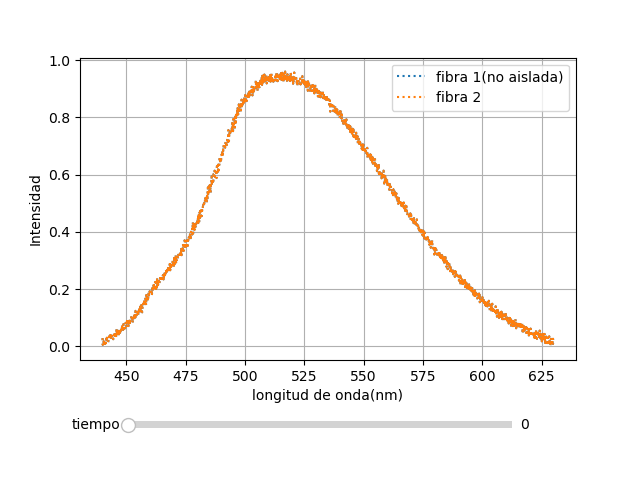

In [67]:
#Visualización de los datos
i = 0 
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)
linesT = [] 
aux, = ax.plot(wavelength, fibra1[i], linestyle = ":", marker = "")
linesT.append(aux)
aux, = ax.plot(wavelength, fibra2[i], linestyle = ":", marker = "")
linesT.append(aux)

labels = ['fibra 1(no aislada)', 'fibra 2']

ax.set_xlabel('longitud de onda(nm)')
ax.set_ylabel('Intensidad')
ax.legend((linesT), (labels), loc='upper right', shadow=False)
ax.grid(True)

ax_d = plt.axes([0.2, 0.1, 0.6, 0.03])
slider_d = Slider(ax_d, 'tiempo', valmin=0, valmax= datos.n-1, valinit=0, valstep=1)
def update(val):
    i = slider_d.val
    linesT[0].set_ydata(fibra1[i])
    linesT[1].set_ydata(fibra2[i])
    fig.canvas.draw_idle()

slider_d.on_changed(update)
plt.show()

In [68]:
"""Normalización para fibra 1, utilizando el ajuste como referencia para
minimizar el efecto del ruido"""
peaks = 3

all_popt = []

for i in range(len(fibra1)):
    toFit = fibra1[i]
    popt, pcov = curve_fit(lorentziana_mult,xdata= wavelength, ydata=toFit, p0 = p0, bounds=(bounds_inf, bounds_sup),
    method="trf")
    all_popt.append(popt)
fit = np.array(fibra1)
unpack = np.empty([len(fit),peaks,len(wavelength)])
for i in range(len(fit)):
    fit[i] = lorentziana_mult(wavelength, *all_popt[i])
    for j in range(peaks):
        unpack[i,j,:] = plotsLorentz(wavelength, j, *all_popt[i])
for i in range(len(fit)):
    maxi = max(fit[i])
    fibra1[i] = fibra1[i]/maxi
print(all_popt[0])
print(p0)

"""Misma normalización para fibra 2"""
all_popt2 = []

for i in range(len(fibra2)):
    toFit = fibra2[i]
    popt, pcov = curve_fit(lorentziana_mult,xdata= wavelength, ydata=toFit, p0 = p0, bounds=(bounds_inf, bounds_sup),
    method="trf")
    all_popt2.append(popt)
fit2 = np.array(fibra2)
unpack2 = np.empty([len(fit2),peaks,len(wavelength)])

for i in range(len(fit)):
    fit2[i] = lorentziana_mult(wavelength, *all_popt2[i])
    for j in range(peaks):
        unpack2[i,j,:] = plotsLorentz(wavelength, j, *all_popt2[i])
for i in range(len(fit)):
    maxi = max(fit2[i])
    fibra2[i] = fibra2[i]/maxi

[-3.13075709e-01  4.43070365e+01  9.82314161e+01  1.74921070e+02
  2.44768641e+01  1.34120750e+02  6.37343027e+01  5.01082683e+02
  5.27496035e+02  5.59214792e+02]
[-3.4827000e-01  4.5647670e+01  4.9052490e+01  7.4921070e+01
  4.6879710e+01  3.4120750e+01  4.9968400e+01  5.0105880e+02
  5.2461706e+02  5.4850106e+02]


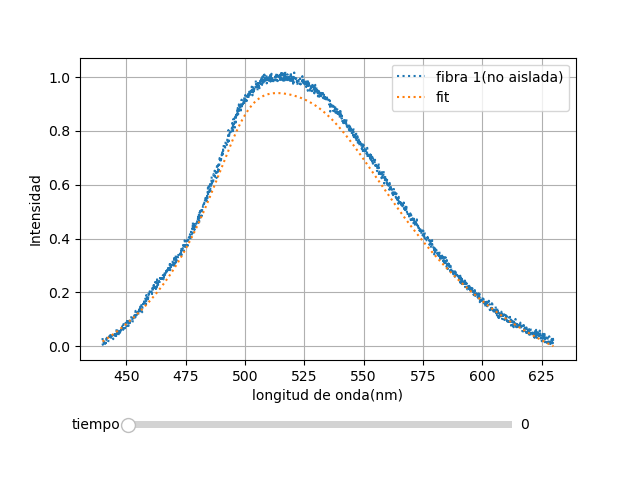

In [69]:
"""Visualización de la normalización, falla de no escoger los parametros
apropiados de ajuste"""
i = 0

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)
linesT = [] 
aux, = ax.plot(wavelength, fibra1[i], linestyle = ":", marker = "")
linesT.append(aux)
aux, = ax.plot(wavelength, fit[i], linestyle = ":", marker = "")
linesT.append(aux)


labels = ['fibra 1(no aislada)', 'fit']

ax.set_xlabel('longitud de onda(nm)')
ax.set_ylabel('Intensidad')
ax.legend((linesT), (labels), loc='upper right', shadow=False)
ax.grid(True)

ax_d = plt.axes([0.2, 0.1, 0.6, 0.03])
slider_d = Slider(ax_d, 'tiempo', valmin=0, valmax= datos.n-1, valinit=0, valstep=1)
def update(val):
    i = slider_d.val
    linesT[0].set_ydata(fibra1[i])
    linesT[1].set_ydata(fit[i])
    fig.canvas.draw_idle()

slider_d.on_changed(update)
plt.show()

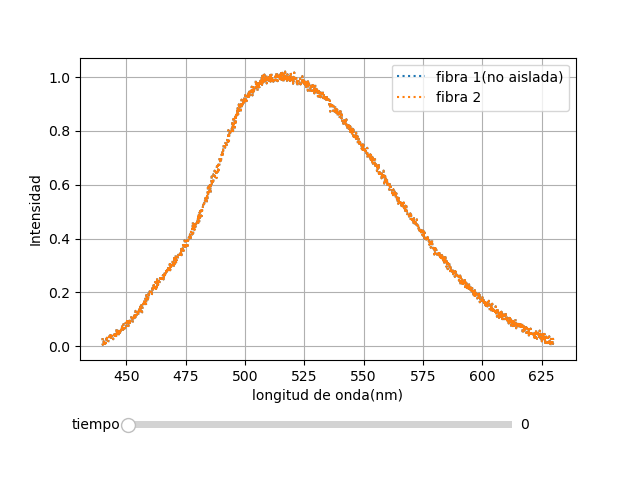

In [70]:
"""Visualización de fibra 1 y 2 después de la normalización, verificar que ambas
sean idénticas en i = 0, si no se está análizando una medición con 2 muestras ignorar"""
i = 0

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)
linesT = [] 
aux, = ax.plot(wavelength, fibra1[i], linestyle = ":", marker = "")
linesT.append(aux)
aux, = ax.plot(wavelength, fibra2[i], linestyle = ":", marker = "")
linesT.append(aux)


labels = ['fibra 1(no aislada)', 'fibra 2']

ax.set_xlabel('longitud de onda(nm)')
ax.set_ylabel('Intensidad')
ax.legend((linesT), (labels), loc='upper right', shadow=False)
ax.grid(True)

ax_d = plt.axes([0.2, 0.1, 0.6, 0.03])
slider_d = Slider(ax_d, 'tiempo', valmin=0, valmax= datos.n-1, valinit=0, valstep=1)
def update(val):
    i = slider_d.val
    linesT[0].set_ydata(fibra1[i])
    linesT[1].set_ydata(fibra2[i])
    fig.canvas.draw_idle()

slider_d.on_changed(update)
plt.show()

In [71]:
"""Cálculo del ajuste """
all_popt = []

cut_first = False #True si se desea quitar la primer componente del ajuste
cut_index = 0     #indice a partir del cual la componente será cortada
sup = np.copy(bounds_sup)
inf = np.copy(bounds_inf)
for i in range(len(fibra1)):
    toFit = fibra1[i]
    if i >= cut_index and cut_first:
        p0 = p02
        popt, pcov = curve_fit(lorentziana_mult,xdata= wavelength, ydata=toFit, p0 = p0, bounds=(bounds_inf2, bounds_sup2),
        method="trf")
        all_popt.append(popt)
        p0 = popt
        continue   
    popt, pcov = curve_fit(lorentziana_mult,xdata= wavelength, ydata=toFit, p0 = p0, bounds=(inf, sup),
    method="trf")
    all_popt.append(popt)
    p0 = popt

In [72]:
fit = np.array(fibra1)
unpack = np.empty([len(fit),peaks,len(wavelength)])
for i in range(len(fit)):
    fit[i] = lorentziana_mult(wavelength, *all_popt[i])
    if i >= cut_index and cut_first:
        unpack[i,0,:] = lorentziana(wavelength, 0, 0,0)
        for j in range(peaks-1):
            unpack[i,j+1,:] = plotsLorentz(wavelength, j, *all_popt[i])  
        continue
    for j in range(peaks):
        unpack[i,j,:] = plotsLorentz(wavelength, j, *all_popt[i])

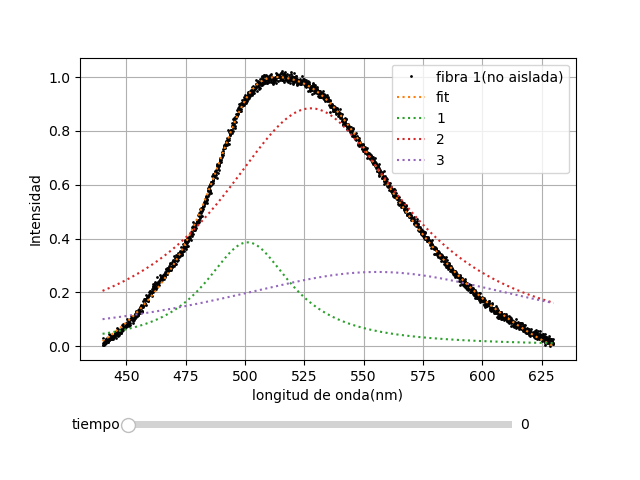

In [73]:
"""Visualización del ajuste"""
i = 0

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)
linesT = [] 
aux, = ax.plot(wavelength, fibra1[i], linestyle = '',marker = 'o', ms=1, mfc='white', mec='black')
linesT.append(aux)
aux, = ax.plot(wavelength, fit[i], linestyle = ":", marker = "")
linesT.append(aux)

for j in range(peaks):
    aux, = ax.plot(wavelength, unpack[i,j], linestyle = ":", marker = "")
    linesT.append(aux)

labels = ['fibra 1(no aislada)', 'fit', '1', '2', '3', '4']

ax.set_xlabel('longitud de onda(nm)')
ax.set_ylabel('Intensidad')
ax.legend((linesT), (labels), loc='upper right', shadow=False)
ax.grid(True)

ax_d = plt.axes([0.2, 0.1, 0.6, 0.03])
slider_d = Slider(ax_d, 'tiempo', valmin=0, valmax= datos.n-1, valinit=0, valstep=1)
def update(val):
    i = slider_d.val
    linesT[0].set_ydata(fibra1[i])
    linesT[1].set_ydata(fit[i])
    for j in range(peaks):
        linesT[j+2].set_ydata(unpack[i,j])
    fig.canvas.draw_idle()

slider_d.on_changed(update)
plt.show()

In [74]:
"""Preparación de parámetros de ajuste para gráficar y guardarse"""
amp = np.zeros(len(fibra1))
amp1 = np.zeros(len(fibra1))
amp2 = np.zeros(len(fibra1))
amp3 = np.zeros(len(fibra1))
for i in range(len(fibra1)):
    if cut_first == True and i >= cut_index:
        amp[i] = all_popt[i][peaks-1+1] + all_popt[i][peaks-1+2]
        amp1[i] = 0.0
        amp2[i] = all_popt[i][peaks-1+1]
        amp3[i] = all_popt[i][peaks-1+2]
        continue
    amp[i] = all_popt[i][peaks+1] + all_popt[i][peaks+2] + all_popt[i][peaks+3]
    amp1[i] = all_popt[i][peaks+1]
    amp2[i] = all_popt[i][peaks+2]
    amp3[i] = all_popt[i][peaks+3]

lambda0 = np.zeros(len(fibra1))
lambda0_1 = np.zeros(len(fibra1))
lambda0_2 = np.zeros(len(fibra1))
lambda0_3 = np.zeros(len(fibra1))
for i in range(len(fibra1)):
    if cut_first == True and i >= cut_index:
        lambda0[i] = all_popt[i][(peaks-1)*2+1] + all_popt[i][(peaks-1)*2+2]
        lambda0_1[i] = 0.0
        lambda0_2[i] = all_popt[i][(peaks-1)*2+1]
        lambda0_3[i] = all_popt[i][(peaks-1)*2+2]
        continue
    lambda0[i] = all_popt[i][peaks*2+1] + all_popt[i][peaks*2+2] + all_popt[i][peaks*2+3]
    lambda0_1[i] = all_popt[i][peaks*2+1]
    lambda0_2[i] = all_popt[i][peaks*2+2]
    lambda0_3[i] = all_popt[i][peaks*2+3]

wid = np.zeros(len(fibra1))
wid1 = np.zeros(len(fibra1))
wid2 = np.zeros(len(fibra1))
wid3 = np.zeros(len(fibra1))
y0 = np.zeros(len(fibra1))
for i in range(len(fibra1)):
    y0[i] = all_popt[i][0]
    if cut_first == True and i >= cut_index:
        wid[i] = all_popt[i][1] + all_popt[i][2]
        wid1[i] = 0.0
        wid2[i] = all_popt[i][1]
        wid3[i] = all_popt[i][2]
        continue
    wid[i] = all_popt[i][1] + all_popt[i][2] + all_popt[i][3]
    wid1[i] = all_popt[i][1]
    wid2[i] = all_popt[i][2]
    wid3[i] = all_popt[i][3]

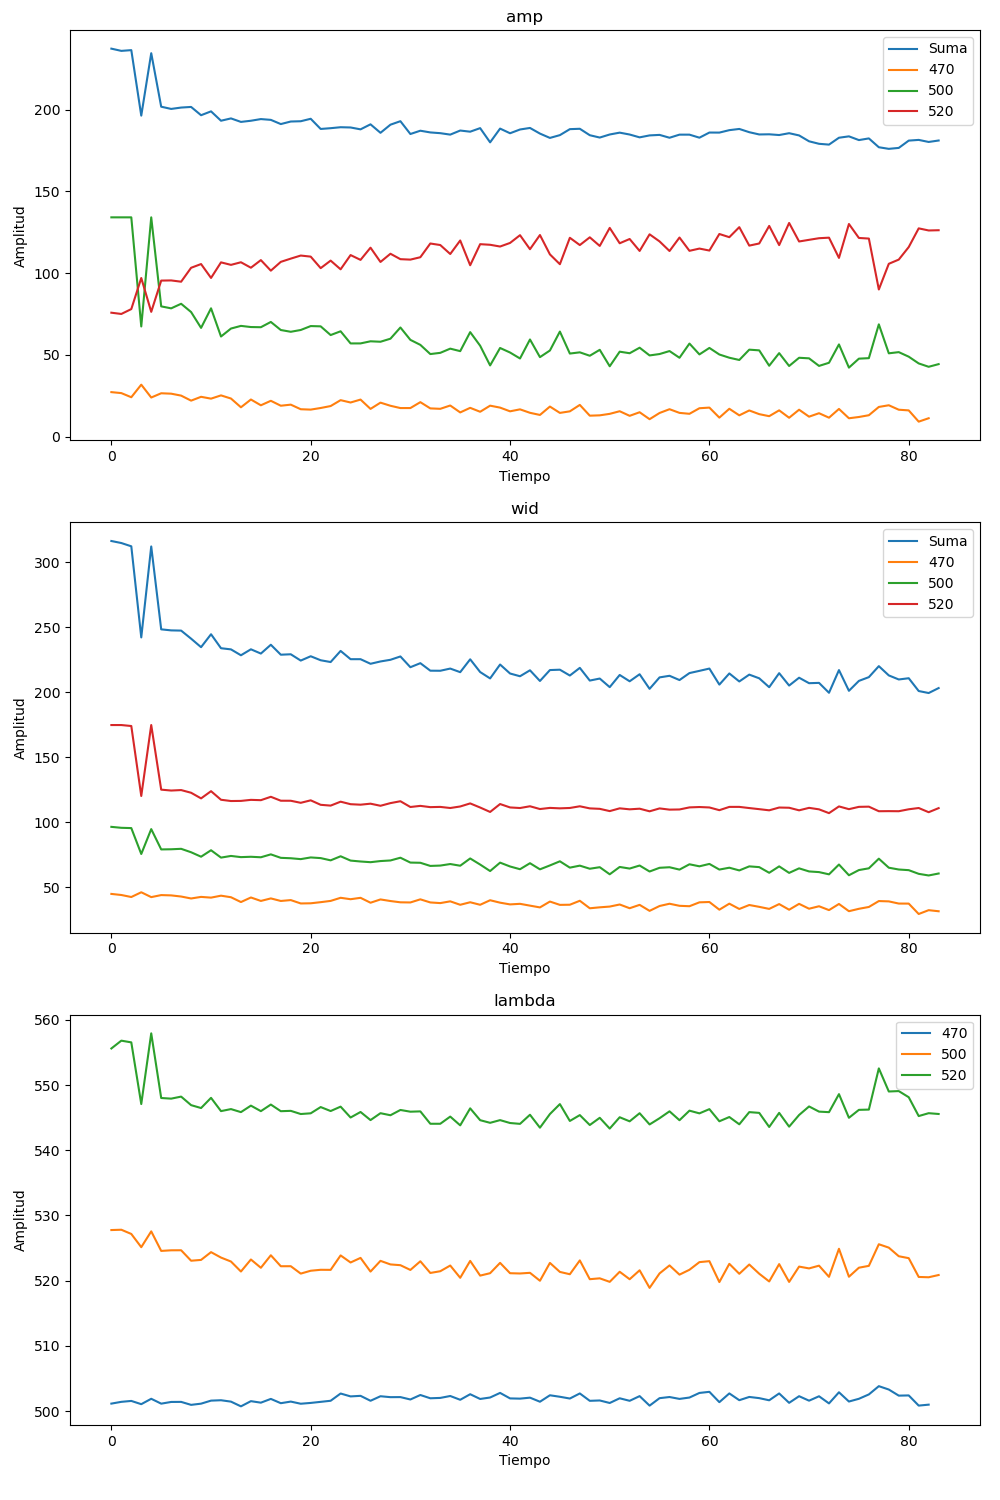

In [75]:
#plt.clf()
"""Visualización de los parámetros de ajuste"""
fig,ax = plt.subplots(3, figsize= (10,15))
plt.subplots_adjust(left=0.07, right=0.98, top=0.98, bottom=0.05)
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel("Amplitud")
plots = []
aux, = ax[0].plot(amp)
plots.append(aux)
aux, = ax[0].plot(amp1[0:83])
plots.append(aux)
aux, = ax[0].plot(amp2)
plots.append(aux)
aux, = ax[0].plot(amp3)
plots.append(aux)
ax[0].legend(plots, ["Suma","470", "500", "520"])
ax[0].set_title('amp')

ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel("Amplitud")
plots = []
aux, = ax[1].plot(wid)
plots.append(aux)
aux, = ax[1].plot(wid1)
plots.append(aux)
aux, = ax[1].plot(wid2)
plots.append(aux)
aux, = ax[1].plot(wid3)
plots.append(aux)
ax[1].legend(plots, ["Suma","470", "500", "520"])
ax[1].set_title('wid')

ax[2].set_xlabel("Tiempo")
ax[2].set_ylabel("Amplitud")
plots = []
aux, = ax[2].plot(lambda0_1[0:83])
plots.append(aux)
aux, = ax[2].plot(lambda0_2)
plots.append(aux)
aux, = ax[2].plot(lambda0_3)
plots.append(aux)
ax[2].legend(plots, ["470", "500", "520"])
ax[2].set_title('lambda')
plt.show()

In [30]:
#version = ''
np.savetxt(ruta_save + version +'amp1.txt', amp1, delimiter=',')
np.savetxt(ruta_save + version +'amp2.txt', amp2, delimiter=',')
np.savetxt(ruta_save + version +'amp3.txt', amp3, delimiter=',')

np.savetxt(ruta_save + version +'wid1.txt', wid1, delimiter=',')
np.savetxt(ruta_save + version +'wid2.txt', wid2, delimiter=',')
np.savetxt(ruta_save + version +'wid3.txt', wid3, delimiter=',')

np.savetxt(ruta_save + version +'lambda1.txt', lambda0_1, delimiter=',')
np.savetxt(ruta_save + version +'lambda2.txt', lambda0_2, delimiter=',')
np.savetxt(ruta_save + version +'lambda3.txt', lambda0_3, delimiter=',')

np.savetxt(ruta_save + version +'y0.txt', y0, delimiter=',')
np.savetxt(ruta_save + version +'datos.txt', fibra1, delimiter = ',')
np.savetxt(ruta_save + version +'wavelength.txt', wavelength, delimiter = ',')

In [76]:
"""Repetir proceso para fibra 2 si se está trabajando con una medición comparativa"""

adjust = False

if adjust:
    for i in range(len(fibra2)):
        fibra2[i] = fibra2[i] - min(fibra2[i])

In [206]:
#peaks = 3

#p0 = np.array([0.0, 10.,20.,20., 10.,90.,100., 465.,500.,520.])
#p0 = np.array([-0.34826999999999997,45.64767,49.05249,74.92107,5.0,34.12075,49.9684,460.0588,524.61706,548.50106])
#p0 = np.array([0.0, 10.,20.,20., 10.,90.,100., 465.,500.,520.])
#p0 = np.array([-0.24, 17.0,80.0,141.0,2.5,93.0,140.0,478.0,515.0,560.0])
all_popt = []

cut_first = False
cut_index = 0
manipulate = False
manipulate_index = 20
sup = np.copy(bounds_sup)
inf = np.copy(bounds_inf)
for i in range(len(fibra2)):
    toFit = fibra2[i]
    if i >= cut_index and cut_first:
        p0 = p02
        popt, pcov = curve_fit(lorentziana_mult,xdata= wavelength, ydata=toFit, p0 = p0, bounds=(bounds_inf2, bounds_sup2),
        method="trf")
        all_popt.append(popt)
        p0 = popt
        continue   
    popt, pcov = curve_fit(lorentziana_mult,xdata= wavelength, ydata=toFit, p0 = p0, bounds=(inf, sup),
    method="trf")
    all_popt.append(popt)
    p0 = popt
    if manipulate and i >= manipulate_index:
        sup[4] = popt[4]-0.05
        inf[4] -= 0.05
        p0[4] = sup[4]
        inf[1] = popt[1]
        sup[1] = inf[1] + 0.001

In [207]:
fit = np.array(fibra2)
unpack = np.empty([len(fit),peaks,len(wavelength)])
for i in range(len(fit)):
    fit[i] = lorentziana_mult(wavelength, *all_popt[i])
    if i >= cut_index and cut_first:
        unpack[i,0,:] = lorentziana(wavelength, 0, 0,0)
        for j in range(peaks-1):
            unpack[i,j+1,:] = plotsLorentz(wavelength, j, *all_popt[i])  
        continue
    for j in range(peaks):
        unpack[i,j,:] = plotsLorentz(wavelength, j, *all_popt[i])

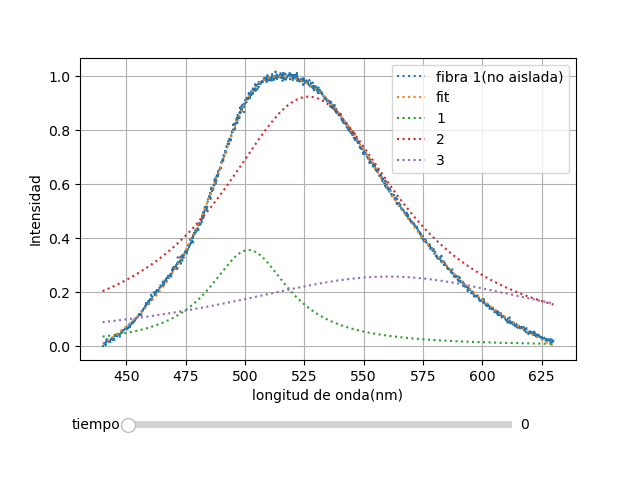

In [208]:
i = 0

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)
linesT = [] 
aux, = ax.plot(wavelength, fibra2[i], linestyle = ":", marker = "")
linesT.append(aux)
aux, = ax.plot(wavelength, fit[i], linestyle = ":", marker = "")
linesT.append(aux)

for j in range(3):
    aux, = ax.plot(wavelength, unpack[i,j], linestyle = ":", marker = "")
    linesT.append(aux)

labels = ['fibra 1(no aislada)', 'fit', '1', '2', '3']

ax.set_xlabel('longitud de onda(nm)')
ax.set_ylabel('Intensidad')
ax.legend((linesT), (labels), loc='upper right', shadow=False)
ax.grid(True)

ax_d = plt.axes([0.2, 0.1, 0.6, 0.03])
slider_d = Slider(ax_d, 'tiempo', valmin=0, valmax= datos.n-1, valinit=0, valstep=1)
def update(val):
    i = slider_d.val
    linesT[0].set_ydata(fibra2[i])
    linesT[1].set_ydata(fit[i])
    for j in range(3):
        linesT[j+2].set_ydata(unpack[i,j])
    fig.canvas.draw_idle()

slider_d.on_changed(update)
plt.show()

In [209]:
amp = np.zeros(len(fibra1))
amp1 = np.zeros(len(fibra1))
amp2 = np.zeros(len(fibra1))
amp3 = np.zeros(len(fibra1))
for i in range(len(fibra1)):
    if cut_first == True and i >= cut_index:
        amp[i] = all_popt[i][peaks-1+1] + all_popt[i][peaks-1+2]
        amp1[i] = 0.0
        amp2[i] = all_popt[i][peaks-1+1]
        amp3[i] = all_popt[i][peaks-1+2]
        continue
    amp[i] = all_popt[i][peaks+1] + all_popt[i][peaks+2] + all_popt[i][peaks+3]
    amp1[i] = all_popt[i][peaks+1]
    amp2[i] = all_popt[i][peaks+2]
    amp3[i] = all_popt[i][peaks+3]

lambda0 = np.zeros(len(fibra1))
lambda0_1 = np.zeros(len(fibra1))
lambda0_2 = np.zeros(len(fibra1))
lambda0_3 = np.zeros(len(fibra1))
for i in range(len(fibra1)):
    if cut_first == True and i >= cut_index:
        lambda0[i] = all_popt[i][(peaks-1)*2+1] + all_popt[i][(peaks-1)*2+2]
        lambda0_1[i] = 0.0
        lambda0_2[i] = all_popt[i][(peaks-1)*2+1]
        lambda0_3[i] = all_popt[i][(peaks-1)*2+2]
        continue
    lambda0[i] = all_popt[i][peaks*2+1] + all_popt[i][peaks*2+2] + all_popt[i][peaks*2+3]
    lambda0_1[i] = all_popt[i][peaks*2+1]
    lambda0_2[i] = all_popt[i][peaks*2+2]
    lambda0_3[i] = all_popt[i][peaks*2+3]

wid = np.zeros(len(fibra1))
wid1 = np.zeros(len(fibra1))
wid2 = np.zeros(len(fibra1))
wid3 = np.zeros(len(fibra1))
y0 = np.zeros(len(fibra1))
for i in range(len(fibra1)):
    y0[i] = all_popt[i][0]
    if cut_first == True and i >= cut_index:
        wid[i] = all_popt[i][1] + all_popt[i][2]
        wid1[i] = 0.0
        wid2[i] = all_popt[i][1]
        wid3[i] = all_popt[i][2]
        continue
    wid[i] = all_popt[i][1] + all_popt[i][2] + all_popt[i][3]
    wid1[i] = all_popt[i][1]
    wid2[i] = all_popt[i][2]
    wid3[i] = all_popt[i][3]

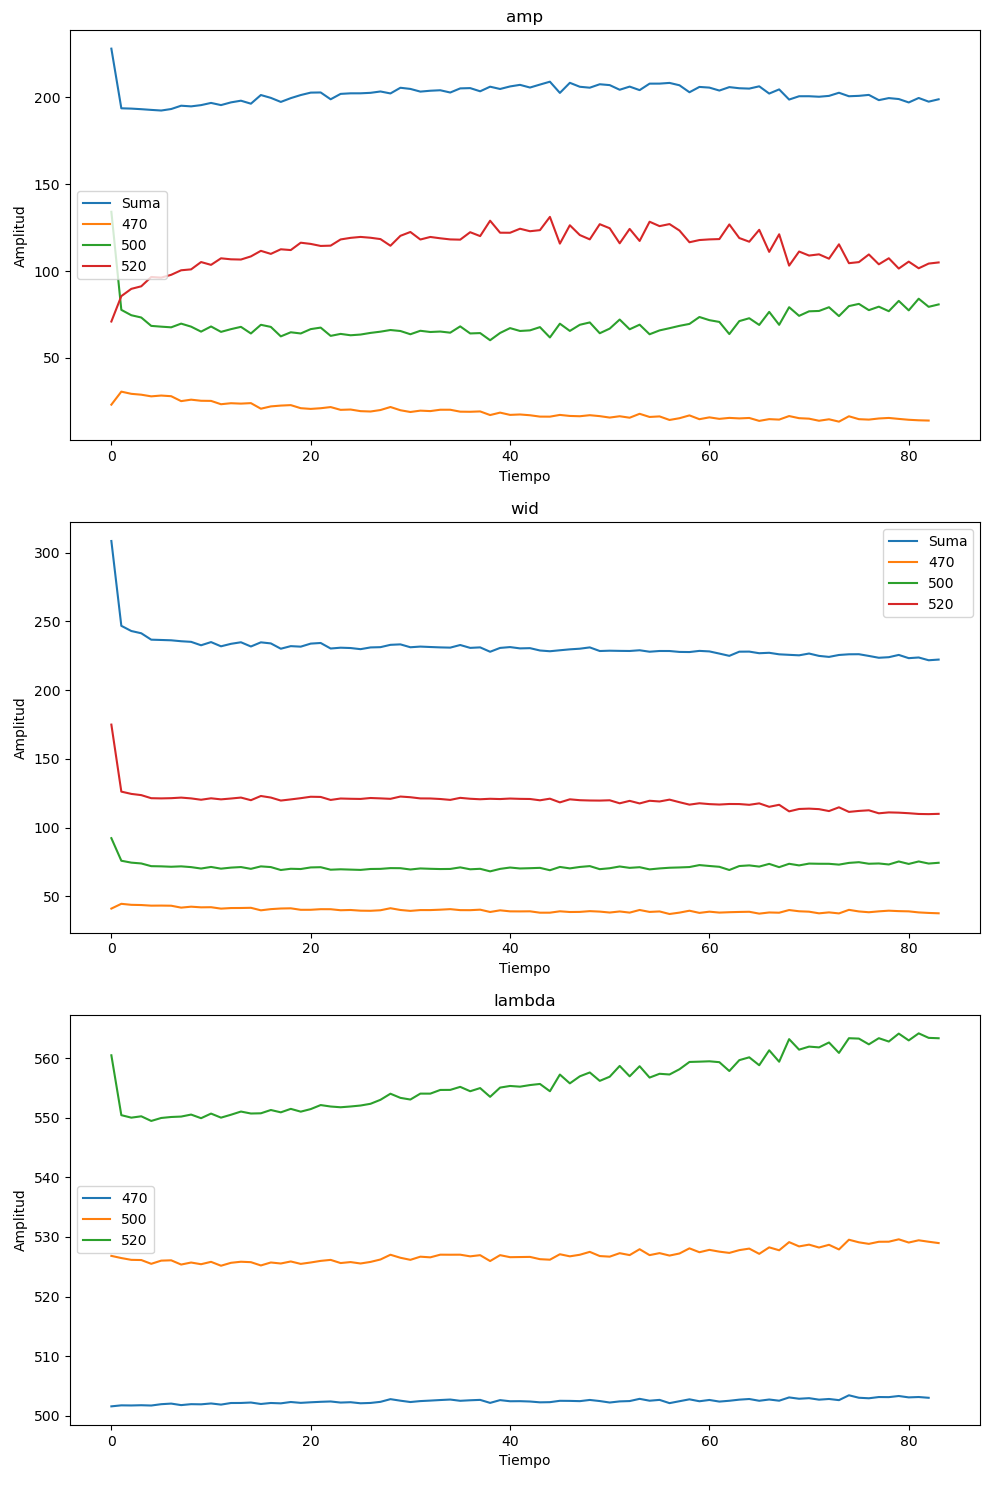

In [210]:
#plt.clf()
fig,ax = plt.subplots(3, figsize= (10,15))
plt.subplots_adjust(left=0.07, right=0.98, top=0.98, bottom=0.05)
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel("Amplitud")
plots = []
aux, = ax[0].plot(amp)
plots.append(aux)
aux, = ax[0].plot(amp1[0:83])
plots.append(aux)
aux, = ax[0].plot(amp2)
plots.append(aux)
aux, = ax[0].plot(amp3)
plots.append(aux)
ax[0].legend(plots, ["Suma","470", "500", "520"])
ax[0].set_title('amp')

ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel("Amplitud")
plots = []
aux, = ax[1].plot(wid)
plots.append(aux)
aux, = ax[1].plot(wid1)
plots.append(aux)
aux, = ax[1].plot(wid2)
plots.append(aux)
aux, = ax[1].plot(wid3)
plots.append(aux)
ax[1].legend(plots, ["Suma","470", "500", "520"])
ax[1].set_title('wid')

ax[2].set_xlabel("Tiempo")
ax[2].set_ylabel("Amplitud")
plots = []
aux, = ax[2].plot(lambda0_1[0:83])
plots.append(aux)
aux, = ax[2].plot(lambda0_2)
plots.append(aux)
aux, = ax[2].plot(lambda0_3)
plots.append(aux)
ax[2].legend(plots, ["470", "500", "520"])
ax[2].set_title('lambda')
plt.show()

In [182]:

np.savetxt(ruta_save + version + 'f2_amp1.txt', amp1, delimiter=',')
np.savetxt(ruta_save + version + 'f2_amp2.txt', amp2, delimiter=',')
np.savetxt(ruta_save + version + 'f2_amp3.txt', amp3, delimiter=',')

np.savetxt(ruta_save + version + 'f2_wid1.txt', wid1, delimiter=',')
np.savetxt(ruta_save + version + 'f2_wid2.txt', wid2, delimiter=',')
np.savetxt(ruta_save + version + 'f2_wid3.txt', wid3, delimiter=',')

np.savetxt(ruta_save + version + 'f2_lambda1.txt', lambda0_1, delimiter=',')
np.savetxt(ruta_save + version + 'f2_lambda2.txt', lambda0_2, delimiter=',')
np.savetxt(ruta_save + version + 'f2_lambda3.txt', lambda0_3, delimiter=',')

np.savetxt(ruta_save + version + 'f2_y0.txt', y0, delimiter=',')
np.savetxt(ruta_save + version + 'f2_datos.txt', fibra2, delimiter = ',')
np.savetxt(ruta_save + version + 'f2_wavelength.txt', wavelength, delimiter = ',')